# Setup

In [ ]:
# Load libraries
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_style("darkgrid")
sns.set_context(context="paper", font_scale=1.5, rc=None)
sns.set(font="serif")

from scipy import stats

# Import data

In [ ]:
df   = pd.read_csv("https://github.com/quarcs-lab/data-quarcs/raw/refs/heads/master/indonesia514/dataBeta.csv")
map  = gpd.read_file("https://github.com/quarcs-lab/data-quarcs/raw/refs/heads/master/indonesia514/mapIdonesia514-opt.geojson")

In [ ]:
df.columns

Index(['districtID', 'district', 'ln_gdppc2010', 'ln_gdppc2018', 'g'], dtype='object')

In [ ]:
map.columns

Index(['districtID', 'district', 'distLongName', 'COORD_X', 'COORD_Y',
       'provinceID', 'province', 'islandID', 'island', 'region', 'regionID',
       'geometry'],
      dtype='object')

In [ ]:
gdf = map.merge(df, on='districtID', how='left')

In [ ]:
gdf.columns

Index(['districtID', 'district_x', 'distLongName', 'COORD_X', 'COORD_Y',
       'provinceID', 'province', 'islandID', 'island', 'region', 'regionID',
       'geometry', 'district_y', 'ln_gdppc2010', 'ln_gdppc2018', 'g'],
      dtype='object')

# Scatterplot with regression fit

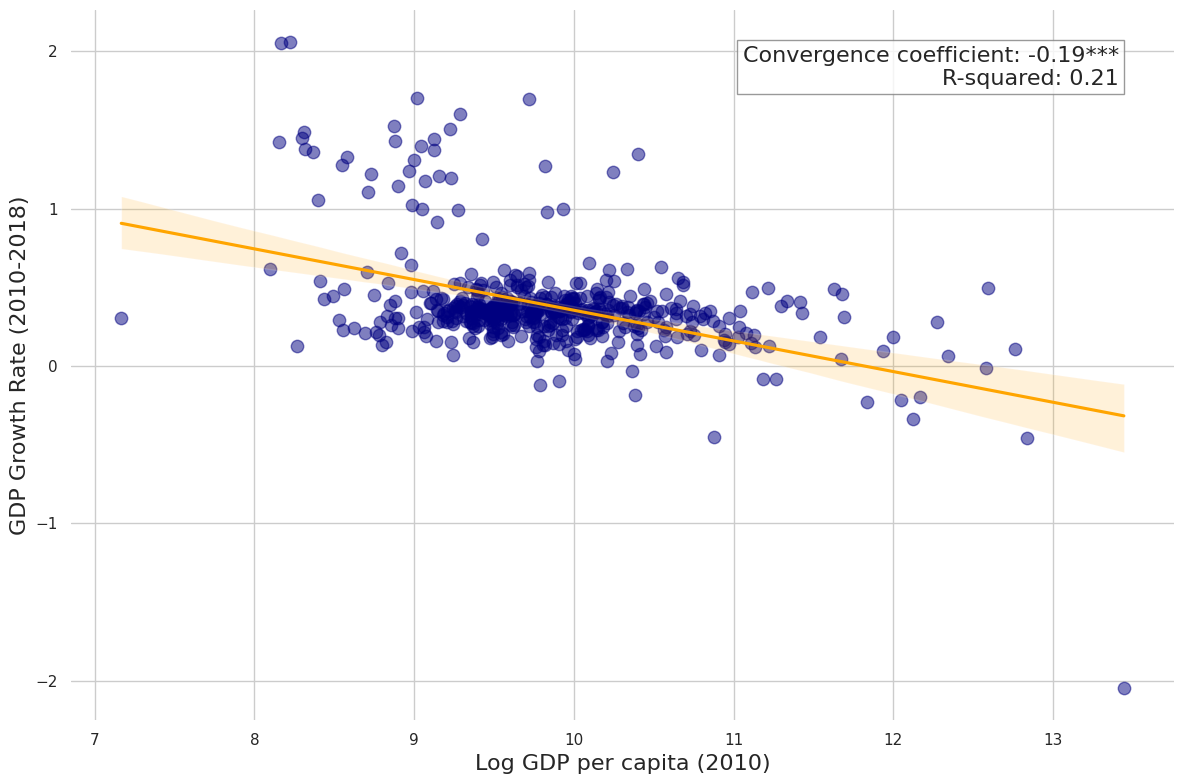

In [ ]:
##################################################################
# Application 1: Regional Growth and Convergence in Indonesia
##################################################################


# 1. Perform Linear Regression Analysis
# -------------------------------------
# Compute the relationship between log GDP per capita (2010)
# and GDP growth rate (2010-2018).

slope, intercept, r_value, p_value, std_err = stats.linregress(
    gdf["ln_gdppc2010"], gdf["g"]
)

# Compute R-squared for goodness of fit
r_squared = r_value**2

# 2. Create Scatterplot with Regression Line
# ------------------------------------------
plt.figure(figsize=(12, 8))  # Set figure size
sns.set_style("whitegrid")   # Apply grid style

# Scatter plot with regression line
ax = sns.regplot(
    x="ln_gdppc2010", y="g", data=gdf,
    scatter_kws={"alpha": 0.5, "color": "navy", "s": 80},
    line_kws={"color": "orange"}
)

# Remove plot spines
sns.despine(left=True, bottom=True)

# 3. Customize Labels and Annotations
# -----------------------------------
plt.xlabel("Log GDP per capita (2010)", fontsize=16)
plt.ylabel("GDP Growth Rate (2010-2018)", fontsize=16)

# Highlight significant coefficients (p < 0.01)
coefficient_text = f"{slope:.2f}{'***' if p_value < 0.01 else ''}"

# Add regression stats box in upper-right corner
plt.text(
    0.95, 0.95,  # Position in axes coordinates
    f"Convergence coefficient: {coefficient_text}\n"
    f"R-squared: {r_squared:.2f}",
    transform=plt.gca().transAxes, fontsize=16,
    verticalalignment="top", horizontalalignment="right",
    bbox=dict(facecolor="white", edgecolor="gray", alpha=0.8)
)

# 4. Improve Layout and Save Figure
# ---------------------------------
plt.tight_layout()  # Optimize layout
plt.savefig("sc.png", dpi=150, bbox_inches="tight")  # Save figure

# 5. Display the Plot
# -------------------
plt.show()  # Show plot
